In [1]:
import warnings
warnings.filterwarnings('ignore')

### Установим красивые дефолтные настройки
### Может быть лень постоянно прописывать
### У графиков параметры цвета, размера, шрифта
### Можно положить их в словарь дефолтных настроек

import matplotlib as mlp

mlp.rcParams['lines.linewidth'] = 5
mlp.rcParams['xtick.major.size'] = 20
mlp.rcParams['xtick.major.width'] = 5
mlp.rcParams['xtick.labelsize'] = 20
mlp.rcParams['xtick.color'] = '#FF5533'

mlp.rcParams['ytick.major.size'] = 20
mlp.rcParams['ytick.major.width'] = 5
mlp.rcParams['ytick.labelsize'] = 20
mlp.rcParams['ytick.color'] = '#FF5533'

mlp.rcParams['axes.labelsize'] = 20
mlp.rcParams['axes.titlesize'] = 20
mlp.rcParams['axes.titlecolor'] = '#00B050'
mlp.rcParams['axes.labelcolor'] = '#00B050'

## Какую задачу решаем сегодня?

<div>
<img src="dataset-cover.png" width="1000"/>
</div>

Мы - команда аналитики в крупной Retail сети гипермаркетов. Наша задача - произвести клиентскую сегментацию. \
В настоящий момент мы можем смотреть на объекты исключительно точечным образом - анализируя отдельные признаки отдельных покупателей. \
Тем не менее, очевидно, что число основных клиентских профилей ограничено. Понимание их состава и отличий друг от друга может помочь бизнесу более грамотно распределять ресурсы, вводить динамические предложения и делать прогнозы метрик по новым покупателям.



*Люди*:

**ID**: Уникальный идентификатор клиента  \
**Year_Birth**: Год рождения покупателя \
**Education**: Уровень образования \
**Marital_Status**: Семейный статус \
**Income**: Годовой доход домохозяйства \
**Kidhome**: Число детей в семье \
**Teenhome**: Число подростков в семье \
**Dt_Customer**: Дата начала работы с компанией \
**Recency**: Числе дней от последней покупки \
**Complain**: Наличие жалоб от клиента последние 2 года 

*Продукты*: 

**MntWines**: Потрачено денег на вино за последние два года \
**MntFruits**: Потрачено денег на фрукты за последние два года \
**MntMeatProducts**: Потрачено денег на мясо за последние два года \
**MntFishProducts**: Потрачено денег на рыбу за последние два года \
**MntSweetProducts**: Потрачено денег на сладости за последние два года \
**MntGoldProds**: Потрачено денег на золото за последние два года 

*Акции и маркетинг*:

**NumDealsPurchases**: Число покупок "со скидкой" \
**AcceptedCmp1**: Воспользовался ли клиент предложением в маркетинговую кампанию №1 \
**AcceptedCmp2**: Воспользовался ли клиент предложением в маркетинговую кампанию №2 \
**AcceptedCmp3**: Воспользовался ли клиент предложением в маркетинговую кампанию №3 \
**AcceptedCmp4**: Воспользовался ли клиент предложением в маркетинговую кампанию №4 \
**AcceptedCmp5**: Воспользовался ли клиент предложением в маркетинговую кампанию №5 \
**Response**: Воспользовался ли клиент предложением в последнюю маркетинговую кампанию

*Каналы*:

**NumWebPurchases**: Число покупок через вебсайт \
**NumCatalogPurchases**: Число покупок, сделанных через каталог \
**NumStorePurchases**: Число покупок, сделанных напрямую в магазине \
**NumWebVisitsMonth**: Число посещений вебсайта компании за последний месяц

In [2]:
### Загрузим данные и изучим их

import pandas as pd
pd.options.display.max_columns = 500

data = pd.read_csv("marketing_campaign.csv")

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


## I. Спецификация задачи

Важное уточнение - зачастую сегментацию производят, если 

1) Есть желание бизнеса посмотреть на профили клиентов без описания конкретных задач и бизнес-кейсов
2) Список вопросов достаточно широкий, оценить эффект моделей сложно и нужно неточное, но комплексное решение

Если ваш сетап достаточно узкий - например, "какие клиенты больше склонны покупать вино" или "как предсказать заранее выручку с клиента", то такие задачи лучше решать как классические задачи обучения с учителем - регрессия или классификация.

## II.Обработка данных и подготовка к валидации

### Очистка

In [3]:
### Проверим пропуски
### Кажется, они есть в единственной колонке - Income

print(data.shape)

data.isna().sum()

(2240, 27)


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Response                0
dtype: int64

In [4]:
### Так как пропусков очень мало относительно размера датасета
### То заменим пропуски константой 
### Здесь нет никакого смысла делить данные на train/test
### Поэтому посчитаем константу и применим ее по всему датасету

data['Income'].fillna(data['Income'].median(), inplace=True)
data.isna().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Response               0
dtype: int64

### Feature Engineering и Feature Selection

Выбор признаков - важнейший этап кластеризации (сегментации). Мы уже знаем, что кластеризация позволяет. Очевидным образом можно заключить, что состав признаков напрямую зависит от ожидаемой ценности разметки, которую получим по результатам выполнения задачи. \
Например, если мы решаем задачу "сегментации клиентов банка для выбора тарифных планов прайсинга по обслуживанию счетов", то стоит брать ту клиентскую информацию, которая действительно может быть связана с особенностями поведения клиентов как пользователей банковских систем. Признак "имя домашнего питомца" только внесет шум в анализ данных. \
В нашей задаче нет четких ожиданий, есть исключительно желание бизнеса понимать клиентские группы. Постараемся применить следующий подход - по минимуму избавляться от фичей, по максимуму вычленять из них полезную информацию.

In [5]:
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0


In [6]:
### Сама по себе фича "Дата начала работы с компанией"  нам вряд ли может быть полезной
### Можно выделить месяц и год как категориальные признаки
### Но они не очень хороши в случае, если мы хотим переиспользовать кластеризацию в будущем
### Куда более интересная фича - "как давно клиент с нами"
### Так как датасет не новый, за дату построения сегментации возьмем "дата присоединения последнего клиента + 7 дней"

data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], format="%d-%m-%Y")
data["Days_from_enrollment"] = (data["Dt_Customer"].max() - data["Dt_Customer"]).apply(lambda x: x.days) + 7
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Days_from_enrollment
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,670
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,120
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,319
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,146
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,168


In [7]:
### Год рождения аналогичным образом не выглядит как хороший признак
### А вот возраст - периодичная относительно датасета величина

data["Age"] = data["Dt_Customer"].max().year - data["Year_Birth"]
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Days_from_enrollment,Age
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,670,57
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,120,60
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,319,49
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,146,30
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,168,33


In [8]:
### Различные траты на различные категории товаров - отличные фичи для профилирования продуктовой корзины
### Для составления высокогранулярных профилей достаточно и смотреть на траты, в целом

costs_columns = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
data['Total_Spent'] = data[costs_columns].sum(axis=1)
data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Days_from_enrollment,Age,Total_Spent
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,670,57,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,120,60,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,319,49,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,146,30,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,168,33,422


In [9]:
### По такой же логике можно поступить с общим числом покупок
### И общей вовлеченностью в маркетинговые кампании

purch_count_columns = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']
accepter_cmps_count_columns = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Response']

data['Total_Purchases'] = data[purch_count_columns].sum(axis=1)
data['Total_Accepted_Companies'] = data[accepter_cmps_count_columns].sum(axis=1)

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,670,57,1617,32,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,120,60,27,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,319,49,776,25,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,146,30,53,14,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,168,33,422,24,0


In [10]:
### Взглянем на различные значения в колонке Marital_Status

data.Marital_Status.unique()

array(['Single', 'Together', 'Married', 'Divorced', 'Widow', 'Alone',
       'Absurd', 'YOLO'], dtype=object)

In [11]:
### Многие из значений дублируют по смыслу семейный статус покупателей
### К тому же, для кластеризации технически выгодно иметь именно бинарные колонки
### Потому что иначе непонятно как кодировать их в числа

data["Marital_Status_v2"] = data["Marital_Status"].replace(
    {
        "Married":"Partner", "Together":"Partner",
        "Absurd":"Alone", "Widow":"Alone", "YOLO":"Alone", "Divorced":"Alone", "Single":"Alone"
    }
)

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies,Marital_Status_v2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,670,57,1617,32,1,Alone
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,120,60,27,11,0,Alone
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,319,49,776,25,0,Partner
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,146,30,53,14,0,Partner
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,168,33,422,24,0,Partner


In [12]:
### Есть ли смысл делить детей по возрасту?
### Для узких задач и анализа продуктовой корзины - да!

data["Children"] = data["Kidhome"] + data["Teenhome"]

### Можно скомбинировать семейный статус и количество детей в общий размер семьи

data["Family_Size"] = data["Marital_Status_v2"].replace({"Alone": 1, "Partner":2}) + data["Children"]

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies,Marital_Status_v2,Children,Family_Size
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,670,57,1617,32,1,Alone,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,120,60,27,11,0,Alone,2,3
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,319,49,776,25,0,Partner,0,2
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,146,30,53,14,0,Partner,1,3
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,168,33,422,24,0,Partner,1,3


In [13]:
### Взглянем на различные значения в колонке Education

data["Education"].value_counts()

Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64

In [14]:
### В целом, данную фичу можно спокойно кодировать, так как фактически она является порядковой
### Но можно упростить детализацию для упрощения потенциальной интерпретации

data["Education_v2"] = data["Education"].replace(
    {
        "Basic":"Undergraduate", "2n Cycle":"Undergraduate",
        "Graduation":"Graduate",
        "Master":"Postgraduate", "PhD":"Postgraduate"
    }
)

data.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies,Marital_Status_v2,Children,Family_Size,Education_v2
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,1,670,57,1617,32,1,Alone,0,1,Graduate
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,0,120,60,27,11,0,Alone,2,3,Graduate
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,0,319,49,776,25,0,Partner,0,2,Graduate
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,0,146,30,53,14,0,Partner,1,3,Graduate
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,0,168,33,422,24,0,Partner,1,3,Postgraduate


In [15]:
### Уберем очевидно ненужные фичи
### А также те, из которых мы вычленили более компактные 
### Датасет стал супер-компактным, а ключевую информацию мы, кажется, сохранили!

cols_to_drop = [
    'ID', 'Year_Birth', 'Education',
    'Marital_Status', 'Kidhome', 'Teenhome',
    'Dt_Customer'
] + costs_columns + purch_count_columns + accepter_cmps_count_columns

data.drop(cols_to_drop, axis=1, inplace=True)
data.head()

,Income,Recency,Complain,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies,Marital_Status_v2,Children,Family_Size,Education_v2
0,58138.0,58,0,670,57,1617,32,1,Alone,0,1,Graduate
1,46344.0,38,0,120,60,27,11,0,Alone,2,3,Graduate
2,71613.0,26,0,319,49,776,25,0,Partner,0,2,Graduate
3,26646.0,26,0,146,30,53,14,0,Partner,1,3,Graduate
4,58293.0,94,0,168,33,422,24,0,Partner,1,3,Postgraduate


In [16]:
data.Education_v2.unique()

array(['Graduate', 'Postgraduate', 'Undergraduate'], dtype=object)

In [17]:
### Финально закодируем категориальные колонки

data['Marital_Status_v2'] = data['Marital_Status_v2'].replace(
    {
        'Alone':0,
        'Partner':1
    }
)

data['Education_v2'] = data['Education_v2'].replace(
    {
        'Undergraduate':0,
        'Graduate':1,
        'Postgraduate':2
    }
)

data.dtypes

Income                      float64
Recency                       int64
Complain                      int64
Days_from_enrollment          int64
Age                           int64
Total_Spent                   int64
Total_Purchases               int64
Total_Accepted_Companies      int64
Marital_Status_v2             int64
Children                      int64
Family_Size                   int64
Education_v2                  int64
dtype: object

### EDA и Обработка выбросов

В задаче обучения с учителем под выбросами мы, в основном, подразумевали выбросы в плане таргетных значений. Так, например, в задаче регрессии такие объекты вносили сильный вклад в расчет ошибки и, соответственно, решение оптимизационной задачи, что в совокупности сильно влияло на итоговый результат. \
Здесь же мы решаем задачу обучения с учителем, и таргета как такового нет. При этом полезно бывает почистить выбросы именно в признаках. \
Они вносят шум в кластеры и "натягивают их на себя", мешая смотреть на кластеры в более общем ключе.

<Figure size 640x480 with 0 Axes>

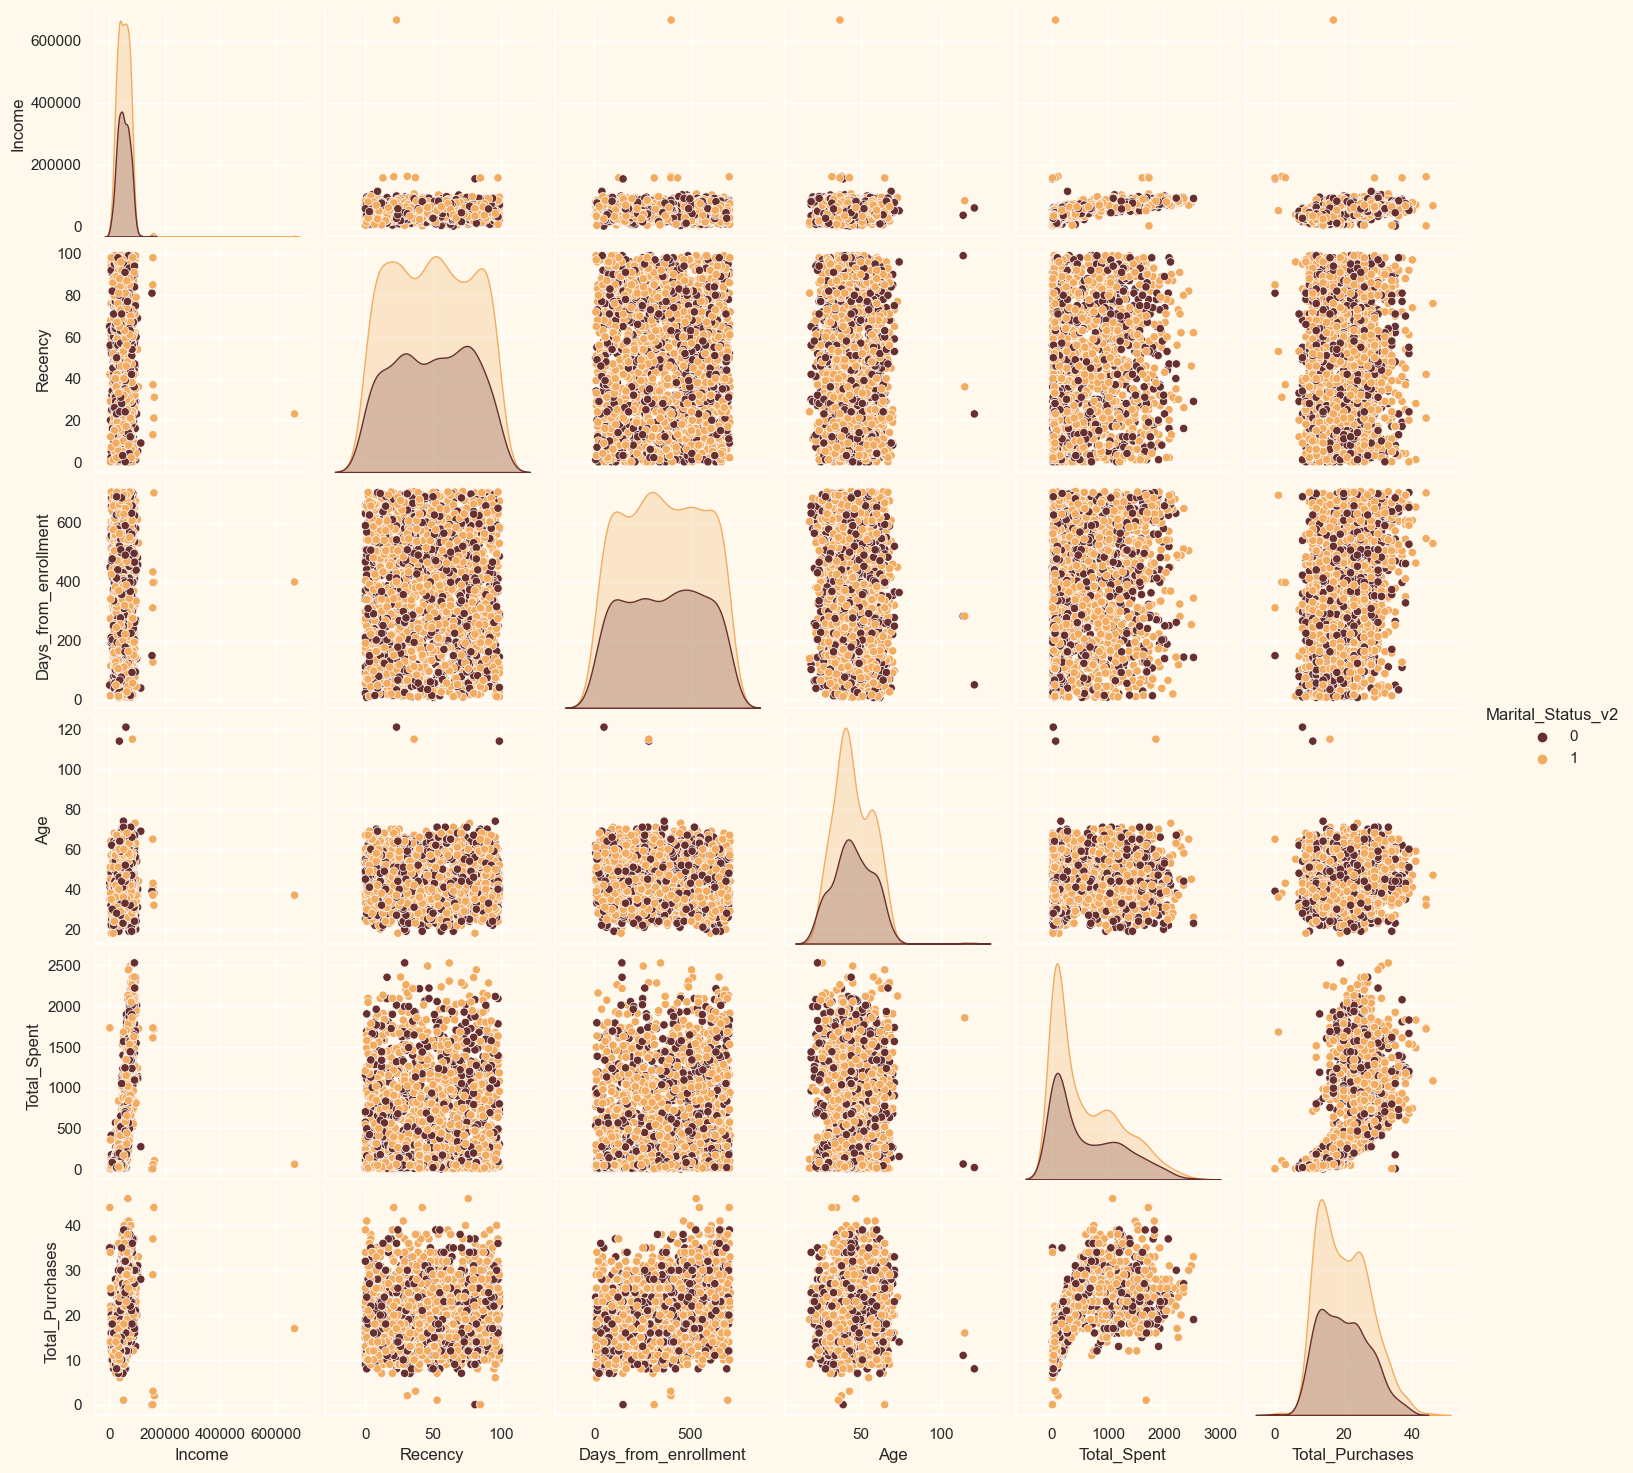

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import colors
from matplotlib.colors import ListedColormap

### Своруем популярную на Kaggle палетку
sns.set(rc={"axes.facecolor":"#FFF9ED","figure.facecolor":"#FFF9ED"})
pallet = ["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"]
cmap = colors.ListedColormap(["#682F2F", "#9E726F", "#D6B2B1", "#B9C0C9", "#9F8A78", "#F3AB60"])

### Изобразим некоторые попарные распределения

To_Plot = [ "Income", "Recency", "Days_from_enrollment", "Age", "Total_Spent", "Total_Purchases", "Marital_Status_v2"]
plt.figure()
sns.pairplot(data[To_Plot], hue= "Marital_Status_v2",palette= (["#682F2F","#F3AB60"]))

plt.show()

In [20]:
### Видим выбросы - по доходу, возрасту
### Почистим их!

data = data[(data["Age"] < 90) & (data["Income"] < 600000)]

print(f"Размер датафрейма стал равен {data.shape[0]}")

data.head()

Размер датафрейма стал равен 2236


,Income,Recency,Complain,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies,Marital_Status_v2,Children,Family_Size,Education_v2
0,58138.0,58,0,670,57,1617,32,1,0,0,1,1
1,46344.0,38,0,120,60,27,11,0,0,2,3,1
2,71613.0,26,0,319,49,776,25,0,1,0,2,1
3,26646.0,26,0,146,30,53,14,0,1,1,3,1
4,58293.0,94,0,168,33,422,24,0,1,1,3,2


### Scaling

В метрических подходах особо важно приводить данные к одному порядку - если распределение какой-то фичи на порядок выше остальных, то распределение объектов по кластеру будет почти совпадать с их распределением по этой фиче. Иначе говоря, чем меньше порядок фичи, тем меньший вклад в формирование кластера она вносит.

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
data_scaled.head()

,Income,Recency,Complain,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies,Marital_Status_v2,Children,Family_Size,Education_v2
0,0.288947,0.306856,-0.095001,1.529793,1.016868,1.680176,1.619794,0.620456,-1.347635,-1.264308,-1.758810,-0.411891
1,-0.262003,-0.383971,-0.095001,-1.191143,1.273264,-0.962202,-1.260794,-0.501987,-1.347635,1.395139,0.445618,-0.411891
2,0.918423,-0.798467,-0.095001,-0.206659,0.333146,0.282541,0.659598,-0.501987,0.742041,-1.264308,-0.656596,-0.411891
3,-1.182183,-0.798467,-0.095001,-1.062517,-1.290693,-0.918994,-0.849281,-0.501987,0.742041,0.065416,0.445618,-0.411891
4,0.296187,1.550344,-0.095001,-0.953679,-1.034298,-0.305762,0.522427,-0.501987,0.742041,0.065416,0.445618,1.123090


### Понижение размерности

Техника, о которой мы вам сейчас расскажем, достаточно популярна во многих задачах машинного обучения. \
Суть состоит в следующем - пусть у нас есть объекты, описанные признаковым пространством размера $d$, то есть $x \in R^d$. \
Скажем, пусть есть $s < d$, тогда снижение размерности сводится к тому, чтобы получить $x \approx x^* \in R^s$. \
Есть целое множество концепций, описывающих как и зачем такое преобразование нужно получать. Из общего - это:

1) Получить более компактное множество
2) Визуализировать данные, являющиеся более, чем трехмерными

Самый базовый подход - метод главных компонент (PCA, principal component analysys). Он заключается в поиске такого $s$-мерного ортонормированного базиса, при отображении в компоненты которого сохраняется "как можно больше информации". 

<div>
<img src="PCA.png" width="700"/>
</div>

В качестве такого критерия можно взять дисперсию по признакам и искать "главные компоненты", решая следующую задачу:

<center>$VaR_{sum} = \sum_j^m \sigma_j^2 = \sum_j \sum_i z_j^2 = \sum_j \sum_i (\sum_i^M w_{ij}\cdot d_j)^2 \rightarrow max$<center>
<center>при условии<center>
<center>$\sum_k^M w_k^2 = 1$<center>

Здесь формула дисперсии записана так, а не иначе, что работает в случае, если данные центрированы. Так как мы делали Standard Scaling, то выборочное среднее по фичам равно нулю, а значит формула сработает корректно!

In [53]:
### Разложим матрицу data на 5 главных компонент

from sklearn.decomposition import PCA

pca = PCA(n_components=5)
pca.fit(data_scaled)
data_pca = pd.DataFrame(pca.transform(data_scaled), columns=[f"PCA_{i+1}" for i in range(5)])
data_pca.head()

,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5
0,3.259852,-0.424969,0.694431,1.743429,0.234751
1,-1.800730,-0.387008,-1.720420,0.670424,0.546150
2,1.262091,-0.029844,0.080211,-0.850930,-0.060098
3,-1.912215,-0.971493,0.186985,-1.553839,0.173836
4,-0.400375,0.588439,-0.405413,-0.260058,-1.665499


In [54]:
### Мы можем посмотреть на доли дисперсий, которые объясняет каждая из компонент

pca.explained_variance_ratio_

array([0.26306861, 0.14393203, 0.10178144, 0.09114604, 0.08473285])

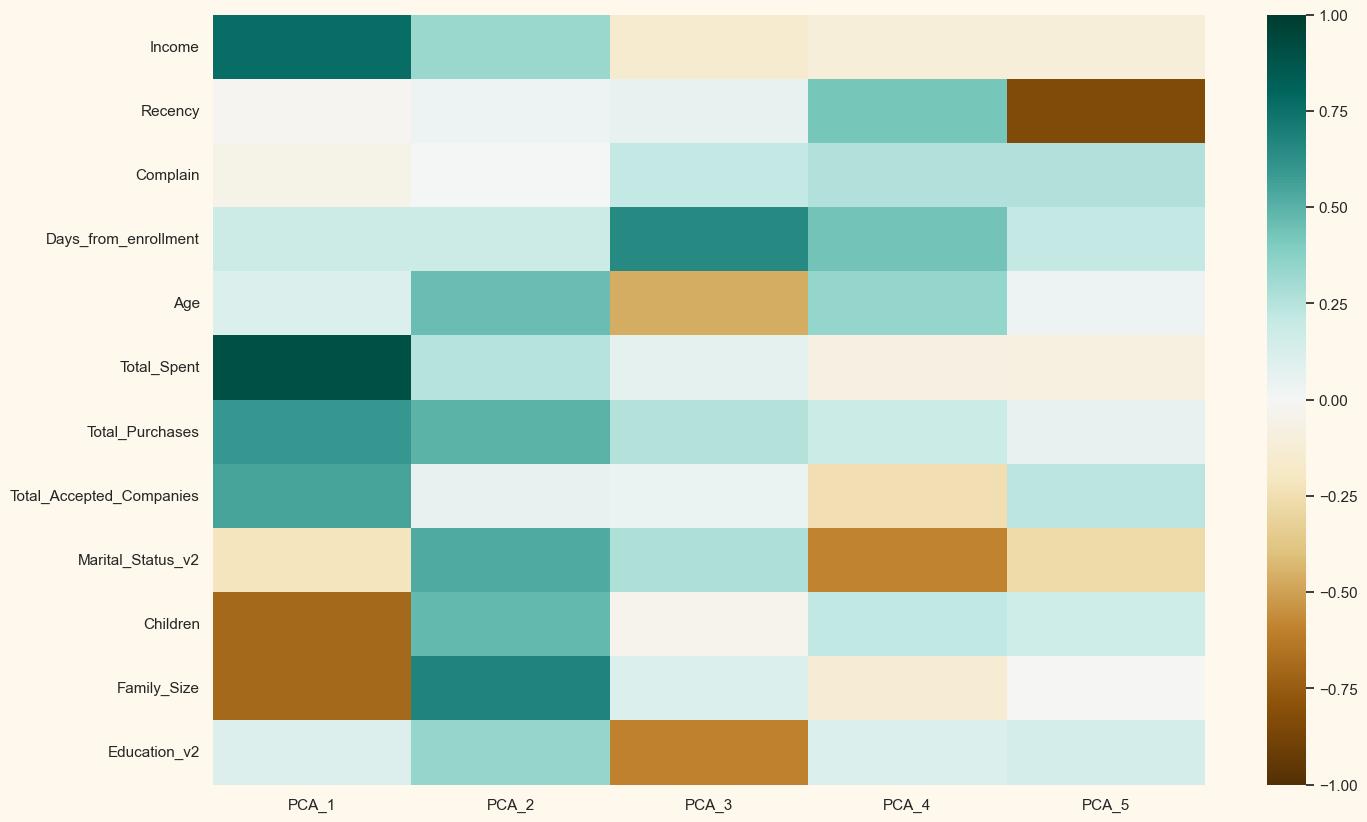

In [56]:
### Также можно изучить "состав" этих компонент - изучив корреляцию с базовыми признаками
### В начале - корреляции под каждую компоненту с фичами
fst_component_corr = data_scaled.corrwith(data_pca.PCA_1)
scnd_component_corr = data_scaled.corrwith(data_pca.PCA_2)
thrd_component_corr = data_scaled.corrwith(data_pca.PCA_3)
frth_component_corr = data_scaled.corrwith(data_pca.PCA_4)
ffth_component_corr = data_scaled.corrwith(data_pca.PCA_5)

### Объединим все в одно место
corrs = pd.concat(
    (
        fst_component_corr,
        scnd_component_corr,
        thrd_component_corr,
        frth_component_corr,
        ffth_component_corr
    ),
    axis=1
)

### Нормально назовем колонки
corrs.columns = [f"PCA_{i+1}" for i in range(5)]

### Изобразим в виде карты
fig = plt.figure()
fig.set_size_inches(16, 10)

sns.heatmap(corrs, 
            xticklabels=corrs.columns,
            yticklabels=corrs.index,
            cmap='BrBG',
            vmin=-1,
            vmax=1)

plt.show()

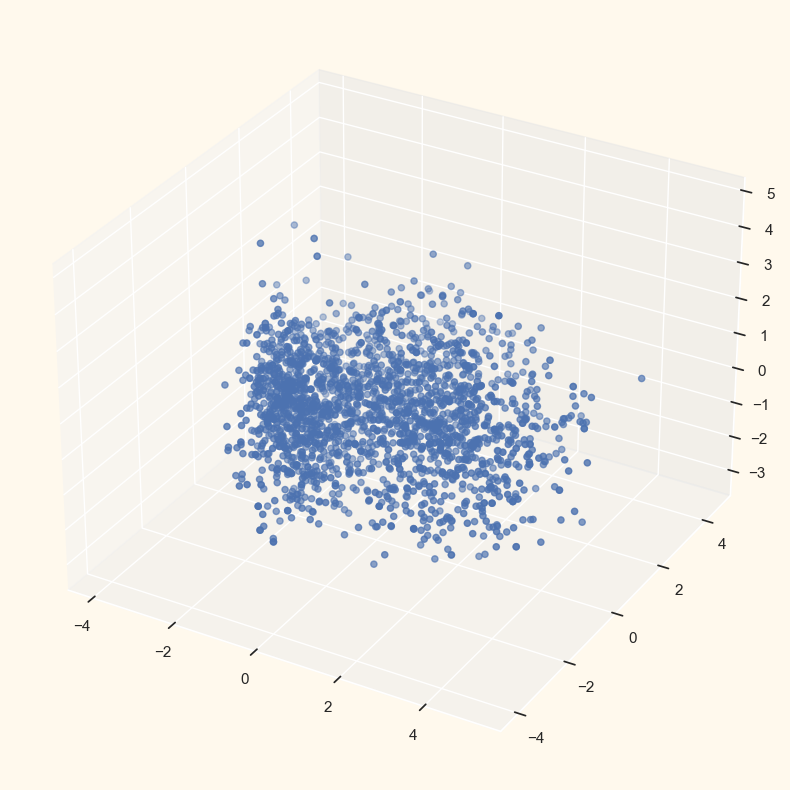

In [58]:
### Можно даже изобразить практически оригинальный датасет по трем первым компонентам!

fig = plt.figure()
fig.set_size_inches(16, 10)

ax = plt.axes(projection='3d')
ax.scatter3D(
    data_pca['PCA_1'], 
    data_pca['PCA_2'],
    data_pca['PCA_3'], 
)

## III. Выбор модели 

В рамках эксперимента изучим оба подхода, которые рассмотрели в презентации - **DBSCAN** и **KMEANS**.

### DBSCAN

In [70]:
### Импортируем класс из модуля cluster
from sklearn.cluster import DBSCAN
import numpy as np

### Далее - по классике инициализируем, применяем fit/transform
### Можем наблюдать результат!
dbscan = DBSCAN(eps=1, min_samples=20)
dbscan.fit(data_pca)
result = dbscan.labels_

### Аналог value_counts, но для np массива в переменной result
unique, counts = np.unique(result, return_counts=True)
print(np.asarray((unique, counts)).T)

[[  -1 1079]
 [   0  669]
 [   1  130]
 [   2  104]
 [   3   79]
 [   4  137]
 [   5   19]
 [   6   19]]


Какую метрику будем использовать? В лекции узнали про межкластерное и внутрикластерное расстояния. Какое из них лучше? \
Как и ранее, на помощь приходят метрики, которые включают в себя сразу несколько базовых! \
Коэффициент силуэта определяется для каждого объекта и состоит из двух баллов:

<center>$s = \cfrac{b-a}{max(b, a)}$</center>

1) **$a$** = Среднее расстояние между объектом и всеми другими точками того же класса.
2) **$b$** = Среднее расстояние между объектом и всеми другими точками в следующем ближайшем кластере.

Коэффициент силуэта для всего датасета дается как среднее значение коэффициента силуэта для каждого объекта.

*Из документации sklearn*:

**Преимущества**: \
Оценка ограничена от -1 за неправильную кластеризацию до +1 за высокоплотную кластеризацию. Баллы около нуля указывают на перекрывающиеся кластеры. \
Оценка выше, когда кластеры плотные и хорошо разделенные, что относится к стандартной концепции кластера. \
**Недостатки**: \
Коэффициент силуэта обычно выше для выпуклых кластеров, чем для других концепций кластеров, таких как кластеры на основе плотности, подобные тем, которые получены с помощью DBSCAN.

In [83]:
### Пример его расчета - ниже

from sklearn.metrics import silhouette_score
silhouette_score(data_pca, result)

-0.1487519927898244

In [112]:
### Можно написать обертку поверх GridSearchCV
### Но в случае DBSCAN куда проще посчитать лучшую "модель" циклом

import itertools

dbscan_grid = {
    'eps': [0.1, 0.3, 0.5, 0.7, 1, 1.5, 2, 2.5, 3, 4, 5],
    'min_samples': [15, 20, 30, 35, 40, 45, 50],
    'metric': ['euclidean', 'manhattan']
}

dbscan_keys, dbscan_values = zip(*dbscan_grid.items())
dbscan_permutations = [dict(zip(dbscan_keys, v)) for v in itertools.product(*dbscan_values)]
dbscan_permutations

[{'eps': 0.1, 'min_samples': 15, 'metric': 'euclidean'},
 {'eps': 0.1, 'min_samples': 15, 'metric': 'manhattan'},
 {'eps': 0.1, 'min_samples': 20, 'metric': 'euclidean'},
 {'eps': 0.1, 'min_samples': 20, 'metric': 'manhattan'},
 {'eps': 0.1, 'min_samples': 30, 'metric': 'euclidean'},
 {'eps': 0.1, 'min_samples': 30, 'metric': 'manhattan'},
 {'eps': 0.1, 'min_samples': 35, 'metric': 'euclidean'},
 {'eps': 0.1, 'min_samples': 35, 'metric': 'manhattan'},
 {'eps': 0.1, 'min_samples': 40, 'metric': 'euclidean'},
 {'eps': 0.1, 'min_samples': 40, 'metric': 'manhattan'},
 {'eps': 0.1, 'min_samples': 45, 'metric': 'euclidean'},
 {'eps': 0.1, 'min_samples': 45, 'metric': 'manhattan'},
 {'eps': 0.1, 'min_samples': 50, 'metric': 'euclidean'},
 {'eps': 0.1, 'min_samples': 50, 'metric': 'manhattan'},
 {'eps': 0.3, 'min_samples': 15, 'metric': 'euclidean'},
 {'eps': 0.3, 'min_samples': 15, 'metric': 'manhattan'},
 {'eps': 0.3, 'min_samples': 20, 'metric': 'euclidean'},
 {'eps': 0.3, 'min_samples': 20

In [113]:
### Пробежимся и зафиксируем по каждому параметру коэффициент силуэта
### Ожидаем невырожденное распределение 

silhouettes = []

for param_combo in dbscan_permutations:
    dbscan.set_params(**param_combo)
    dbscan.fit(data_pca)
    result = dbscan.labels_

    if len(set(result)) >= 3:
        silhouette_ = silhouette_score(data_pca, result)
        silhouettes.append(silhouette_)
    else:
        silhouettes.append(-100)

print(f"Лучшее значение выбранной метрики равно {max(silhouettes)}")
print(f"Достигается при параметрах {dbscan_permutations[silhouettes.index(max(silhouettes))]}")

Лучшее значение выбранной метрики равно 0.09817845567053402
Достигается при параметрах {'eps': 2.5, 'min_samples': 35, 'metric': 'manhattan'}


In [114]:
### Зафиксируем модель при лучших параметрах и посмотрим на распределение объектов по кластерам

dbscan.set_params(**dbscan_permutations[silhouettes.index(max(silhouettes))])
dbscan.fit(data_pca)
result = dbscan.labels_

unique, counts = np.unique(result, return_counts=True)
print(np.asarray((unique, counts)).T)

[[  -1  330]
 [   0 1868]
 [   1   38]]


### KMEANS

In [120]:
### Для начала протестируем "пример" работы алгоритма

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)
kmeans.fit(data_pca)

print(f"Значение коэффициента силуэта {silhouette_score(data_pca, kmeans.labels_)}")

unique, counts = np.unique(kmeans.labels_, return_counts=True)
print(np.asarray((unique, counts)).T)

Значение коэффициента силуэта 0.20098353413862827
[[  0 759]
 [  1 751]
 [  2 726]]


In [133]:
### Провалидируем по параметрам!

silhouettes = []

for clusters_num in range(3, 15):
    kmeans.set_params(**{'n_clusters':clusters_num})
    kmeans.fit(data_pca)
    result = kmeans.labels_

    silhouette_ = silhouette_score(data_pca, result)
    silhouettes.append(silhouette_)

silhouettes

[0.20096515434093465,
 0.181586454707648,
 0.18082261775552796,
 0.18755117341590308,
 0.19563501072859324,
 0.1928366141448077,
 0.18705919043191577,
 0.18645512723934698,
 0.18403363006917614,
 0.18630582498175355,
 0.18780933149233625,
 0.18417209935598314]

In [135]:
### Зафиксируем лучшую модель и добавим метку кластера в датасет

kmeans.set_params(**{'n_clusters':3})
kmeans.fit(data_pca)
result = kmeans.labels_

data['Cluster'] = result
data.head()

,Income,Recency,Complain,Days_from_enrollment,Age,Total_Spent,Total_Purchases,Total_Accepted_Companies,Marital_Status_v2,Children,Family_Size,Education_v2,Cluster
0,58138.0,58,0,670,57,1617,32,1,0,0,1,1,1
1,46344.0,38,0,120,60,27,11,0,0,2,3,1,0
2,71613.0,26,0,319,49,776,25,0,1,0,2,1,1
3,26646.0,26,0,146,30,53,14,0,1,1,3,1,2
4,58293.0,94,0,168,33,422,24,0,1,1,3,2,0


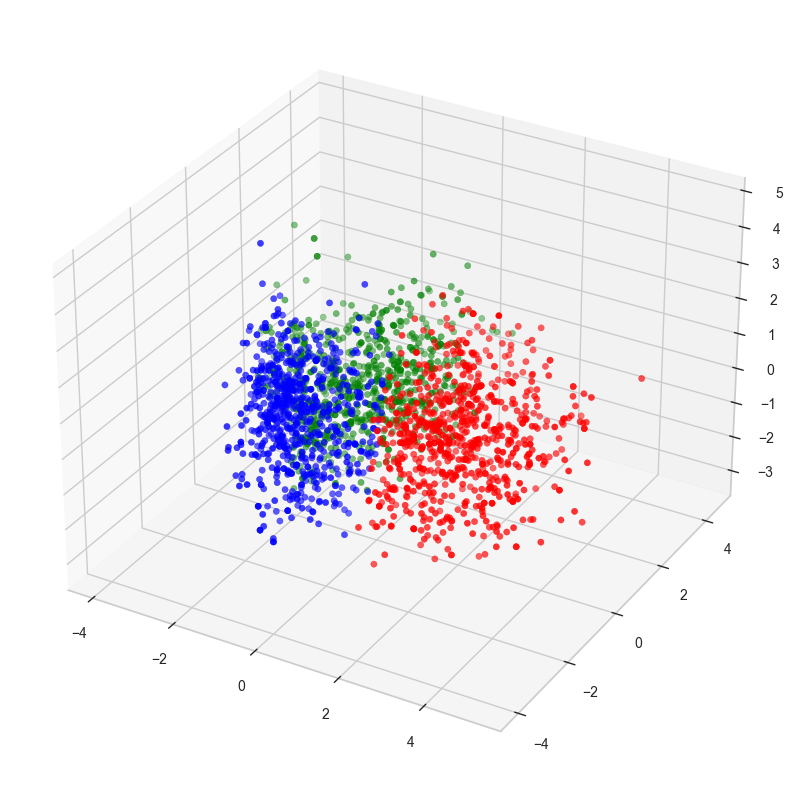

In [137]:
### Разметим результат работы KMeans в координатах главных компонент

fig = plt.figure()
fig.set_size_inches(16, 10)

colors = data['Cluster'].replace([0, 1, 2],
                                            ['green', 'red', 'blue'])

ax = plt.axes(projection='3d')
ax.scatter3D(
    data_pca['PCA_1'], 
    data_pca['PCA_2'],
    data_pca['PCA_3'], 
    c=colors
)

## VI. Интерпретация результатов

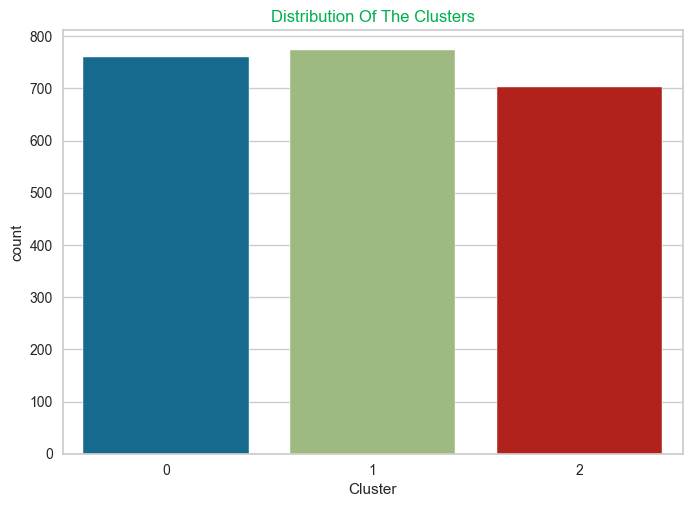

In [141]:
### Начнем с изучения распределение объектов по кластерам
### Видно, что число объектов примерно одинаковое!
### Это можно считать хорошим знаком, если не ожидалось обратного (выявление аномальных кластеров)

pl = sns.countplot(x=data["Cluster"])
pl.set_title("Distribution Of The Clusters")
plt.show()

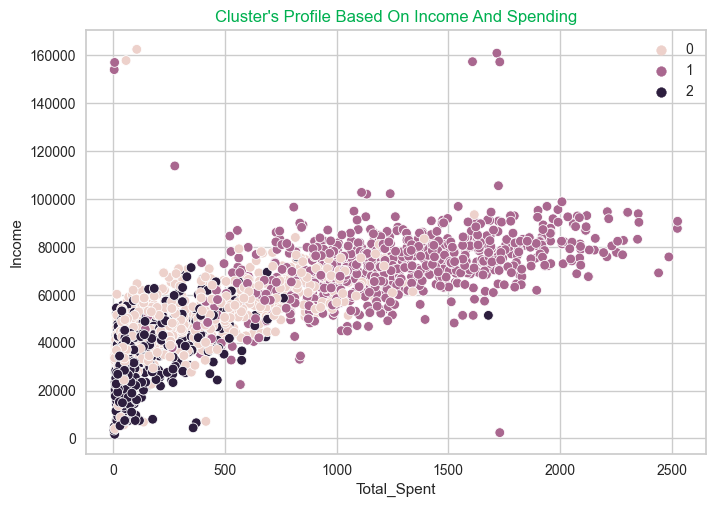

In [143]:
### Какой профиль покупателей в разных кластерах в терминах трат и доходов?
### Видно, что полученные кластеры хорошо описывают 3 группы клиентов по указанным признакам:
### 0 - умеренные показатели
### 1 - высокий уровень доходов и трат
### 2 - низкий уровень доходов и трат

pl = sns.scatterplot(
    data=data,
    x=data["Total_Spent"],
    y=data["Income"],
    hue=data["Cluster"]
)

pl.set_title("Cluster's Profile Based On Income And Spending")
plt.legend()
plt.show()

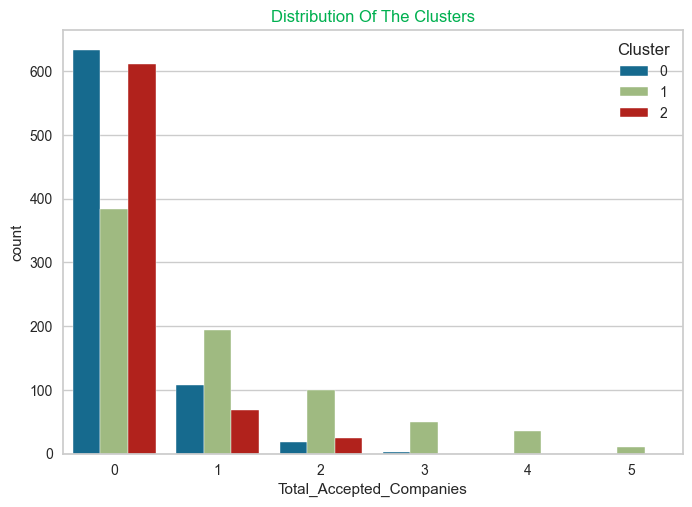

In [145]:
### Что касается успеха в маркетинге?
### 0 - Низкая склонность к взаимодействию
### 1 - Яркая склонность 
### 2 - Низкая склонность к взаимодействию
### Интересный результат - "богатые" не скупятся на выгодные предложения

pl = sns.countplot(x=data["Total_Accepted_Companies"], hue=data["Cluster"])
pl.set_title("Distribution Of The Clusters")
plt.show()

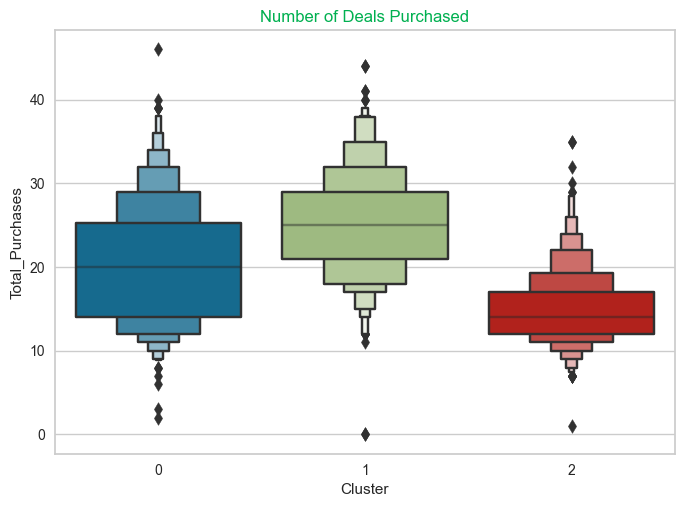

In [148]:
### А что по активности в плане количества покупок?

plt.figure()
pl=sns.boxenplot(
    y=data["Total_Purchases"],
    x=data["Cluster"]
)

pl.set_title("Number of Deals Purchased")
plt.show()

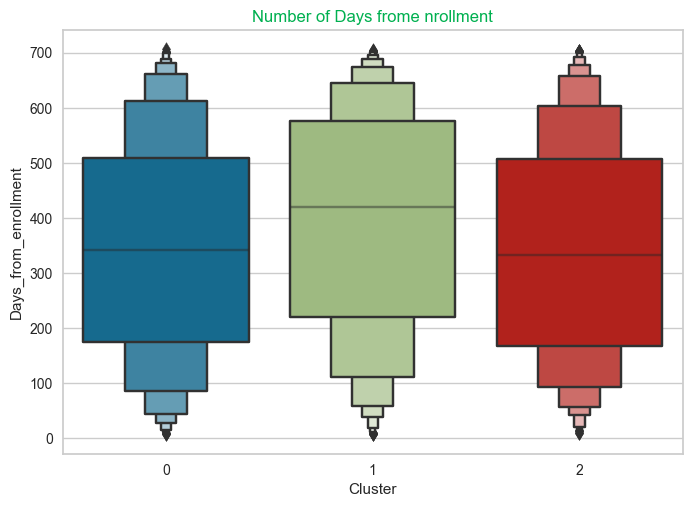

In [230]:
### Аналогично по длительности взаимодействия

plt.figure()
pl=sns.boxenplot(
    y=data["Days_from_enrollment"],
    x=data["Cluster"]
)

pl.set_title("Number of Days frome nrollment")
plt.show()

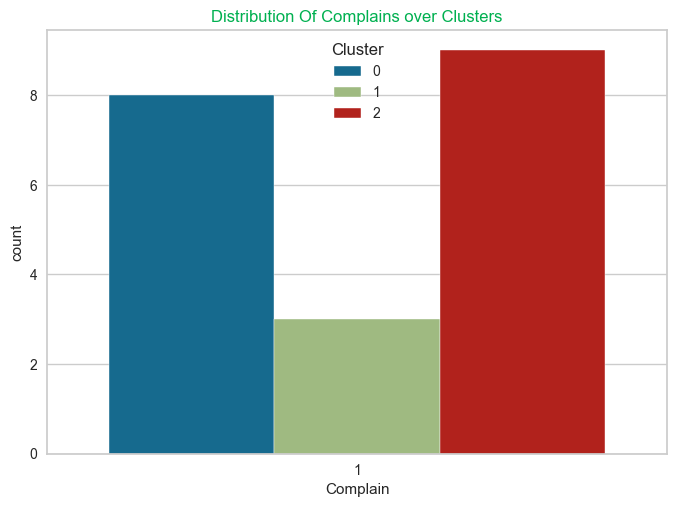

In [153]:
### Жалуются ли разные группы с разной частотой?
### Небольшие отличия есть!

pl = sns.countplot(x=data[data.Complain>0]["Complain"], hue=data["Cluster"])
pl.set_title("Distribution Of Complains over Clusters")
plt.show()

<Figure size 800x550 with 0 Axes>

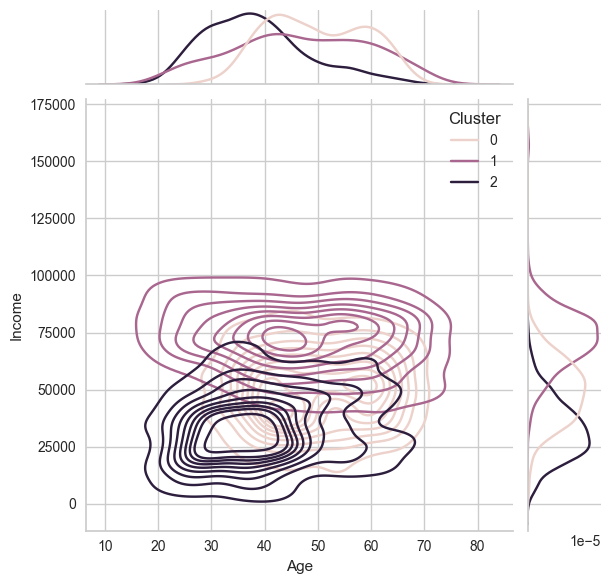

<Figure size 800x550 with 0 Axes>

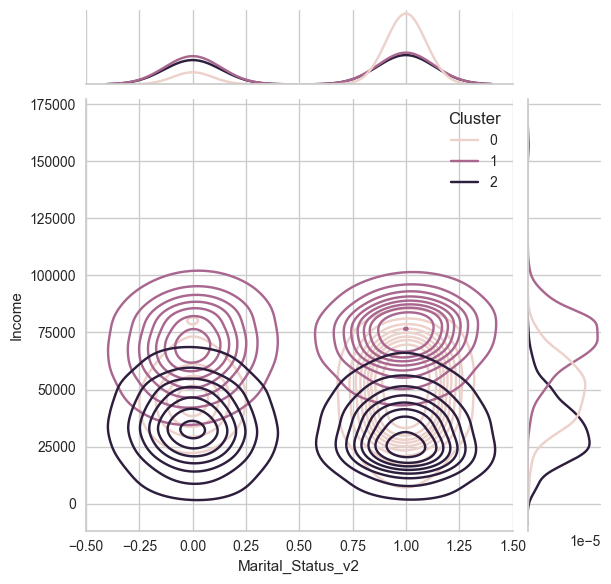

<Figure size 800x550 with 0 Axes>

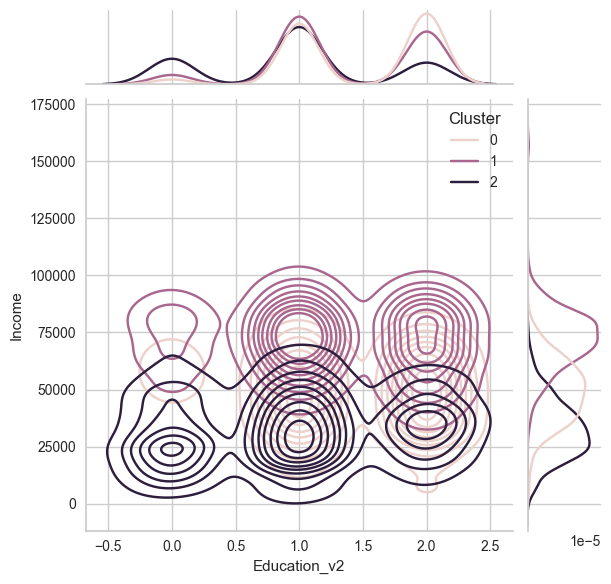

<Figure size 800x550 with 0 Axes>

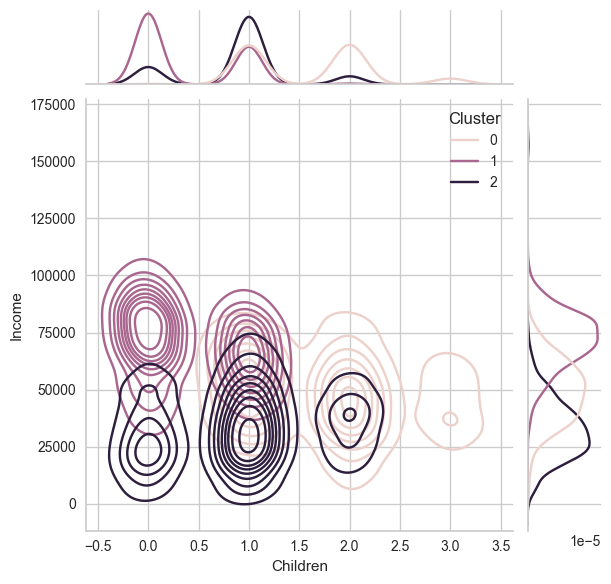

<Figure size 800x550 with 0 Axes>

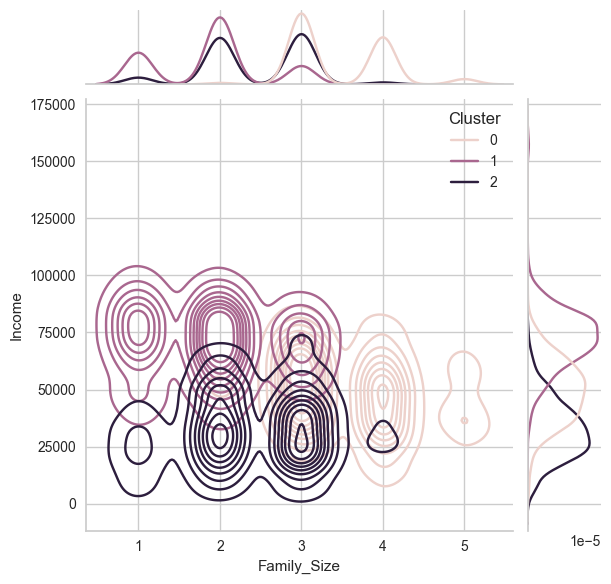

In [152]:
### Теперь изучим профили в разрезе возраста, размера семьи и пр.
### Совместно с доходом домохозяйства

family_compositions = ['Age', 'Marital_Status_v2', 'Education_v2', 'Children', 'Family_Size']

for col in family_compositions:
    plt.figure()
    sns.jointplot(
        x=data[col],
        y=data["Income"],
        hue=data["Cluster"],
        kind="kde"
    )
    plt.show()

По результатам анализа можно составить **карту** полученных кластеров! \
Для презентации ее еще можно местами дополнить статистикой - конкретными цифрами

- *Кластер №0*:
1) Самая возрастная группа, средний возраст клиентов - 50 лет
2) Имеет средний уровень дохода (~49k)
3) Соответственно, умеренный уровень трат (370)
4) Это самый "женатый" кластер и, соответственно, многодетный (1.6 на домохозяйство) - всего у 5 покупателей нет детей
5) Самые образованные покупатели
- *Кластер №1*:
1) Средний возраст слабо отличается от Кластера №0 - 47 лет
2) Тем не менее, это самая высокодоходная группа домохозяйств (~72k)
3) Логично, с самым высоким уровнем трат (1275)
4) Самые малочисленные семьи - в среднем, 1.9 человека
5) Есть гипотеза, что в основном группу составляют одинокие люди или родители-одиночки
6) Самые "довольные" покупатели
7) С огромным отрывом принимали участие в наибольшем числе маркетинговых активностей
- *Кластер №2*:
1) Люди с самым низким уровнем дохода 
2) Самая молодая группа, средний возраст покупателей - 38 лет
3) Соответственно, самый необразованный кластер
4) У подавляющего числа покупателей всего 1 ребенок
5) Самая жалующаяся и отказывающаяся от предложений группа